# 09 · What explains the disagreement between seeds? (all scored targets, self-filling)

**The question.** Five head-fine-tuned models (N=300, seeds 0 to 4) score every compound slightly differently. Which compounds do they disagree on, and what predicts it? If the disagreement could be predicted from the score, the chemistry or the similarity to the training set, it would be a usable uncertainty signal; if not, it is training noise.

**The outcome.** For each of the ~50,000 evaluation compounds per target, the variance across the five seeds of the head-FT **logit** (log-odds of the binary affinity head), converted to a rank between 0 and 1 within the target. The logit and not the probability is used on purpose: a probability near 0 or 1 cannot move much, so the variance of probabilities is mostly a property of the sigmoid (section 1 shows this).

**The method.** LightGBM regression with 3-fold cross-validation on the whole evaluation set. **R2** is the share of the outcome's variance predicted on held-out compounds (0 = nothing, 1 = everything; it can be slightly negative). **AUC** is for the question 'is this compound in the most-disagreed-on quarter?' (0.5 = chance). Rank correlations (Spearman) are not used as the main tool because the relations are not monotone and several features act together.

**Feature groups.** *Score*: mean head-FT logit, No-FT logit, and their difference (how far fine-tuning moved the compound). *Chemistry*: ten RDKit properties (MW, heavy atoms, logP, TPSA, rings, aromatic rings, H-bond donors, H-bond acceptors, rotatable bonds, fsp3; formal charge is constant in these libraries and is left out) plus two substructure flags (Brenk, NIH; PAINS flags nothing here). *Tanimoto*: highest ECFP4 similarity to the 300 training compounds and to the training actives. *Other scores*: Boltz-2 dataset score, Boltzina, its docking score, GNINA, Vina. *ECFP*: 2,048 ECFP4 bits.

Results are computed by `pipeline_local/variance_drivers.py` and cached per target; this notebook only reads them.

In [1]:

import sys, warnings, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
sys.path.insert(0, "/global/scratch/users/sergiomar10/boltzaff/pipeline_local")
import bft_common as bc
bc.style(); pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120); pd.set_option("display.float_format", lambda x: f"{x:.2f}")
SH = bc.SHORT; BLK = bc.BLK; COL = ["#2a78d6", "#eb6834", "#1baf7a", "#8e44ad", "#c9a227", "#7f7f7f"]
def load(name):
    fs = [(t, bc.AN / t / name) for t in bc.TARGETS if (bc.AN / t / name).exists()]
    return pd.concat([pd.read_csv(f, dtype={"target": str}) for _, f in fs], ignore_index=True) if fs else pd.DataFrame()
DR, PDP, SDD, EB = load("variance_drivers.csv"), load("variance_pdp.csv"), load("variance_score_deciles.csv"), load("variance_ecfp_bits.csv"); DRS = load("variance_drivers_scaffold.csv")
TG = sorted(DR.target.unique(), key=lambda s: [SH[t] for t in bc.TARGETS].index(s)) if len(DR) else []
missing = [SH[t] for t in bc.TARGETS if SH[t] not in TG]
print("targets analysed:", TG, "| pending (no result file yet):", missing)
def sel(a): return DR[DR.analysis == a].pivot(index="feature", columns="target", values="R2")[TG] if len(DR) else pd.DataFrame()
def bars(tab, title, xlabel, order=None, ref=None, figsize=(9, None)):
    """horizontal bars = median over targets, dots = individual targets"""
    tab = tab.copy(); tab["median"] = tab.median(1); tab = tab.sort_values("median") if order is None else tab.loc[order]
    h = figsize[1] or 0.32 * len(tab) + 1.2; fig, ax = plt.subplots(figsize=(figsize[0], h)); y = np.arange(len(tab))
    ax.barh(y, tab["median"], color="#c9d8f0", edgecolor=BLK, linewidth=.5, height=.7)
    for k, t in enumerate(TG): ax.scatter(tab[t], y, s=16, color=COL[k % 6], label=t, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(tab.index); ax.set_xlabel(xlabel); ax.set_title(title, fontsize=10); lo = min(0, np.nanmin(tab[TG].values) * 1.1); ax.set_xlim(lo, None)
    if ref is not None: ax.axvline(ref, color=BLK, lw=.8, ls="--")
    ax.legend(title="target", fontsize=7, title_fontsize=7, loc="lower right"); plt.tight_layout(); plt.show(); return tab


targets analysed: ['588689', '504329', '743445', '485317', '2097', '493091'] | pending (no result file yet): ['2650', '588549']


## 1. Does a higher score mean less disagreement?
Median across-seed SD by decile of the head-FT score (decile 0 = lowest scores, 9 = highest), once on the probability scale and once on the logit scale.

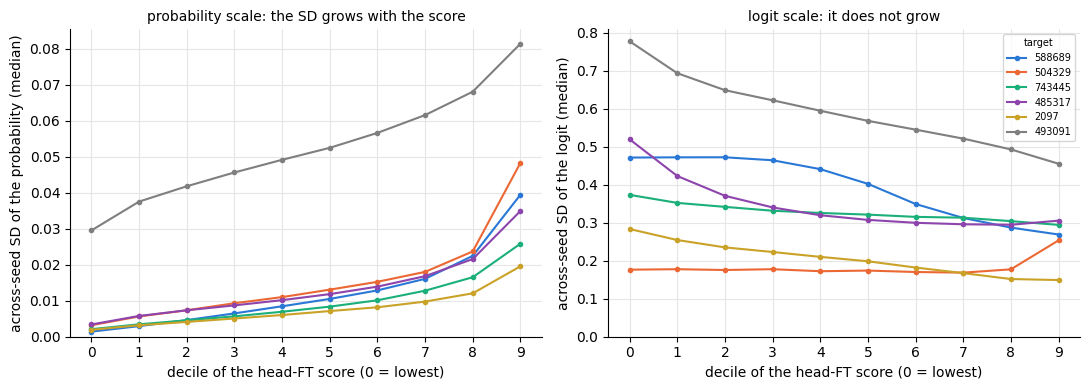

,"SD of probability, lowest decile","SD of probability, highest decile","SD of logit, lowest decile","SD of logit, highest decile"
target,,,,
588689,0.00,0.04,0.47,0.27
504329,0.00,0.05,0.18,0.25
743445,0.00,0.03,0.37,0.29
485317,0.00,0.03,0.52,0.31
2097,0.00,0.02,0.28,0.15
493091,0.03,0.08,0.78,0.46


In [2]:
if not len(SDD): print("pending")
else:
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    for k, t in enumerate(TG):
        d = SDD[SDD.target == t]; axs[0].plot(d.bin, d.sd_prob, marker="o", ms=3, color=COL[k % 6], label=t); axs[1].plot(d.bin, d.sd_logit, marker="o", ms=3, color=COL[k % 6], label=t)
    for ax, ttl, yl in zip(axs, ["probability scale: the SD grows with the score", "logit scale: it does not grow"], ["across-seed SD of the probability (median)", "across-seed SD of the logit (median)"]):
        ax.set_xlabel("decile of the head-FT score (0 = lowest)"); ax.set_ylabel(yl); ax.set_title(ttl, fontsize=10); ax.set_ylim(0, None); ax.set_xticks(range(10))
    axs[1].legend(title="target", fontsize=7, title_fontsize=7); plt.tight_layout(); plt.show()
    f = SDD.groupby("target").apply(lambda d: pd.Series({"SD of probability, lowest decile": d.sd_prob.iloc[0], "SD of probability, highest decile": d.sd_prob.iloc[-1], "SD of logit, lowest decile": d.sd_logit.iloc[0], "SD of logit, highest decile": d.sd_logit.iloc[-1]}))
    display(f.loc[TG])

## 2. How much does each feature group explain, on its own?
R2 of a model that sees only that group (dots: targets; bar: median).

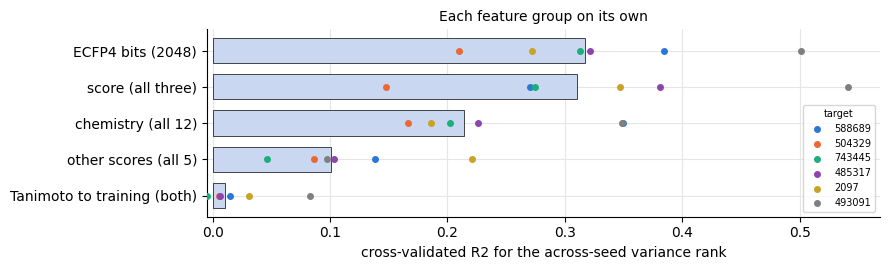

target,588689,504329,743445,485317,2097,493091,median
feature,,,,,,,
ECFP4 bits (2048),0.38,0.21,0.31,0.32,0.27,0.50,0.32
score (all three),0.27,0.15,0.27,0.38,0.35,0.54,0.31
chemistry (all 12),0.35,0.17,0.20,0.23,0.19,0.35,0.21
other scores (all 5),0.14,0.09,0.05,0.10,0.22,0.10,0.10
Tanimoto to training (both),0.02,0.01,-0.00,0.01,0.03,0.08,0.01


AUC for 'top quarter of variance':


target,588689,504329,743445,485317,2097,493091,median
feature,,,,,,,
ECFP4 bits (2048),0.79,0.72,0.77,0.80,0.76,0.86,0.78
Tanimoto to training (both),0.56,0.55,0.51,0.57,0.59,0.66,0.57
chemistry (all 12),0.77,0.69,0.73,0.75,0.71,0.80,0.74
other scores (all 5),0.67,0.67,0.62,0.68,0.72,0.65,0.67
score (all three),0.75,0.72,0.77,0.85,0.79,0.89,0.78


In [3]:
A = sel("alone")
if not len(A): print("pending")
else:
    groups = ["score (all three)", "chemistry (all 12)", "ECFP4 bits (2048)", "Tanimoto to training (both)", "other scores (all 5)"]; A2 = A.loc[[g for g in groups if g in A.index]].copy()
    bars(A2, "Each feature group on its own", "cross-validated R2 for the across-seed variance rank")
    display(A2.assign(median=A2.median(1)).sort_values("median", ascending=False))
    T = DR[(DR.analysis == "alone") & DR.feature.isin(groups)].pivot(index="feature", columns="target", values="AUC")[TG]; print("AUC for 'top quarter of variance':"); display(T.assign(median=T.median(1)))

## 3. Inside the chemistry: which properties, and are they redundant?
Two views. *Alone*: a model that sees one property. *Leave one out*: the model with the score and all chemistry, minus one feature or one group; the drop in R2 is what that feature contributes that nothing else covers. Properties that overlap (MW, heavy atoms, rings) show a small drop each because the others stand in, so groups are also removed together.

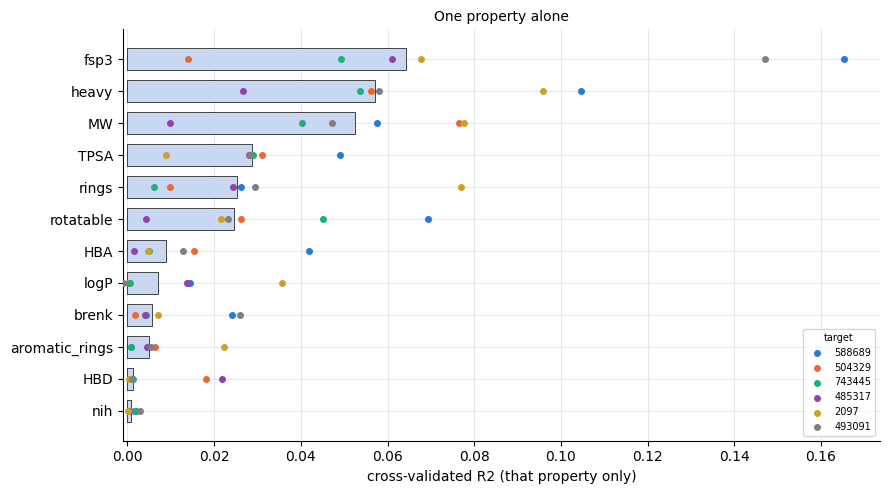

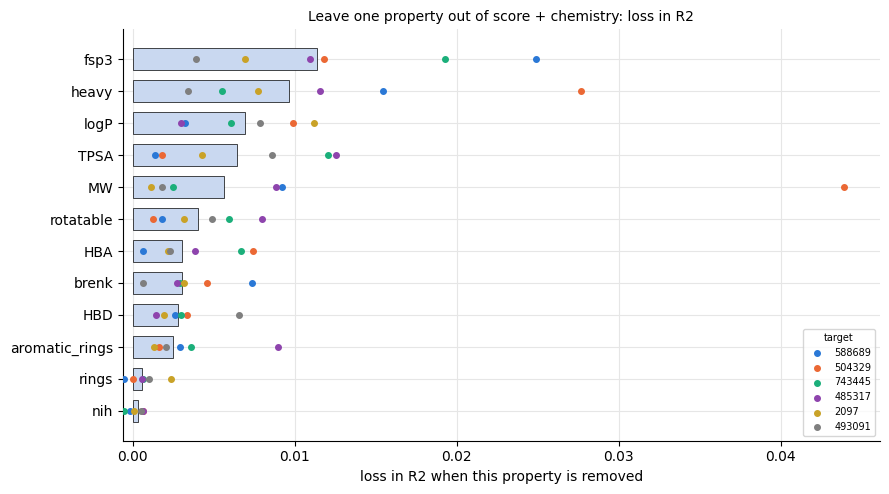

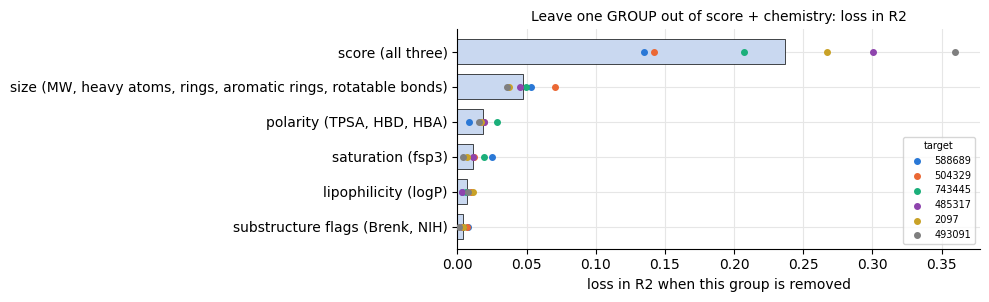

R2 of score + chemistry with nothing removed:


target,588689,504329,743445,485317,2097,493091,median
R2,0.48,0.31,0.41,0.53,0.45,0.71,0.47


In [4]:
A = sel("alone"); L1 = sel("score + chemistry: leave one out"); LG = sel("score + chemistry: leave one group out"); FULL = sel("score + chemistry: nothing removed")
if not len(A) or not len(FULL): print("pending")
else:
    chem = ["MW", "heavy", "logP", "TPSA", "rings", "aromatic_rings", "HBD", "HBA", "rotatable", "fsp3", "brenk", "nih"]
    bars(A.loc[[c for c in chem if c in A.index]], "One property alone", "cross-validated R2 (that property only)")
    full = FULL.loc["-"]; drop1 = (-(L1.sub(full, axis=1))).loc[[c for c in chem if c in L1.index]]
    bars(drop1, "Leave one property out of score + chemistry: loss in R2", "loss in R2 when this property is removed")
    dropg = (-(LG.sub(full, axis=1)))
    bars(dropg, "Leave one GROUP out of score + chemistry: loss in R2", "loss in R2 when this group is removed", figsize=(10, None))
    print("R2 of score + chemistry with nothing removed:"); display(pd.DataFrame({"R2": full}).T.assign(median=full.median()))

## 4. What is complementary to the score?
(a) The score plus one chemistry group: R2 gained over the score alone. (b) What is left after the score: a model of the score (out-of-fold) is fitted first, and each feature group then tries to predict its residual. A group that works in (b) carries information the score does not; one that does not work is redundant with it or irrelevant.

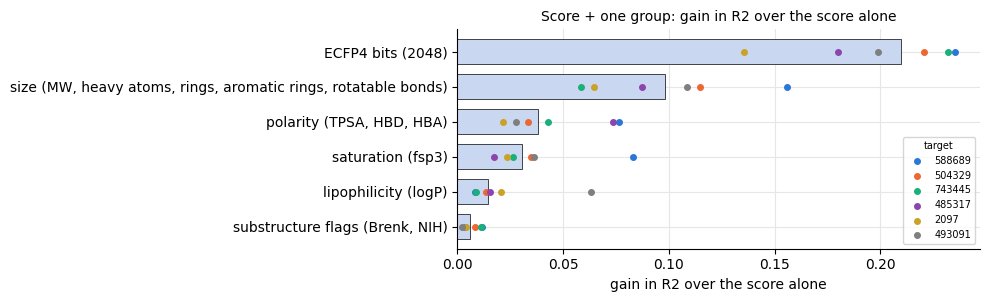

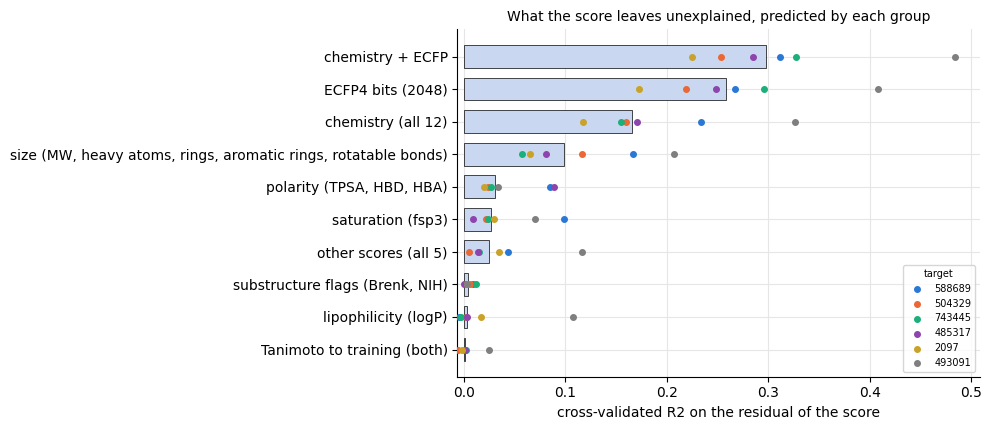

target,588689,504329,743445,485317,2097,493091,median
feature,,,,,,,
chemistry + ECFP,0.31,0.25,0.33,0.29,0.22,0.48,0.30
ECFP4 bits (2048),0.27,0.22,0.30,0.25,0.17,0.41,0.26
chemistry (all 12),0.23,0.16,0.15,0.17,0.12,0.33,0.17
"size (MW, heavy atoms, rings, aromatic rings, rotatable bonds)",0.17,0.12,0.06,0.08,0.07,0.21,0.10
"polarity (TPSA, HBD, HBA)",0.08,0.02,0.03,0.09,0.02,0.03,0.03
saturation (fsp3),0.10,0.02,0.02,0.01,0.03,0.07,0.03
other scores (all 5),0.04,0.00,0.02,0.01,0.04,0.12,0.03
"substructure flags (Brenk, NIH)",0.01,0.01,0.01,0.00,0.00,0.00,0.00
lipophilicity (logP),-0.00,0.00,-0.00,0.00,0.02,0.11,0.00


score alone, median R2: 0.31


In [5]:
A = sel("alone"); P1 = sel("score + one chemistry group"); R = sel("on the residual of the score")
if not len(A) or not len(R): print("pending")
else:
    s0 = A.loc["score (all three)"]
    gain = P1.sub(s0, axis=1); bars(gain, "Score + one group: gain in R2 over the score alone", "gain in R2 over the score alone", figsize=(10, None))
    grp = [i for i in R.index if i in ("chemistry (all 12)", "chemistry + ECFP", "ECFP4 bits (2048)", "Tanimoto to training (both)", "other scores (all 5)")] + [g for g in R.index if "(" in g and ("size" in g or "polarity" in g or "lipophilicity" in g or "saturation" in g or "flags" in g)]
    bars(R.loc[grp], "What the score leaves unexplained, predicted by each group", "cross-validated R2 on the residual of the score", figsize=(10, None))
    display(R.loc[grp].assign(median=R.loc[grp].median(1)).sort_values("median", ascending=False))
    print("score alone, median R2: %.2f" % s0.median())

## 5. In which direction? Variance rank by decile of each property
Each line is one target; the y axis is the median rank of the across-seed variance (0.5 = average compound), the x axis the decile of the property (flags: without / with). The residual panel version (what is left after the score) is in the second figure.

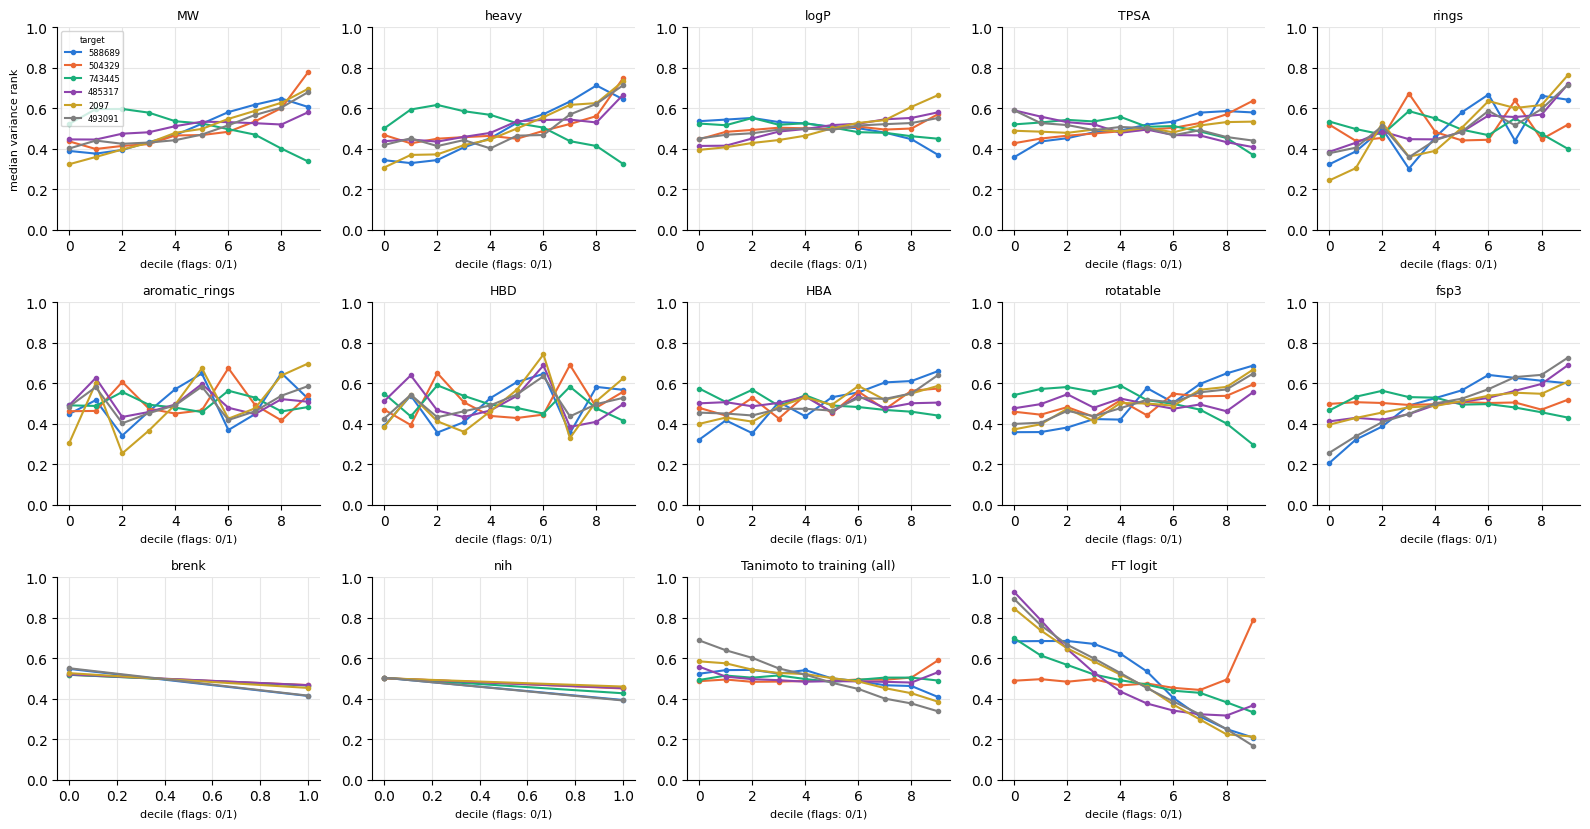

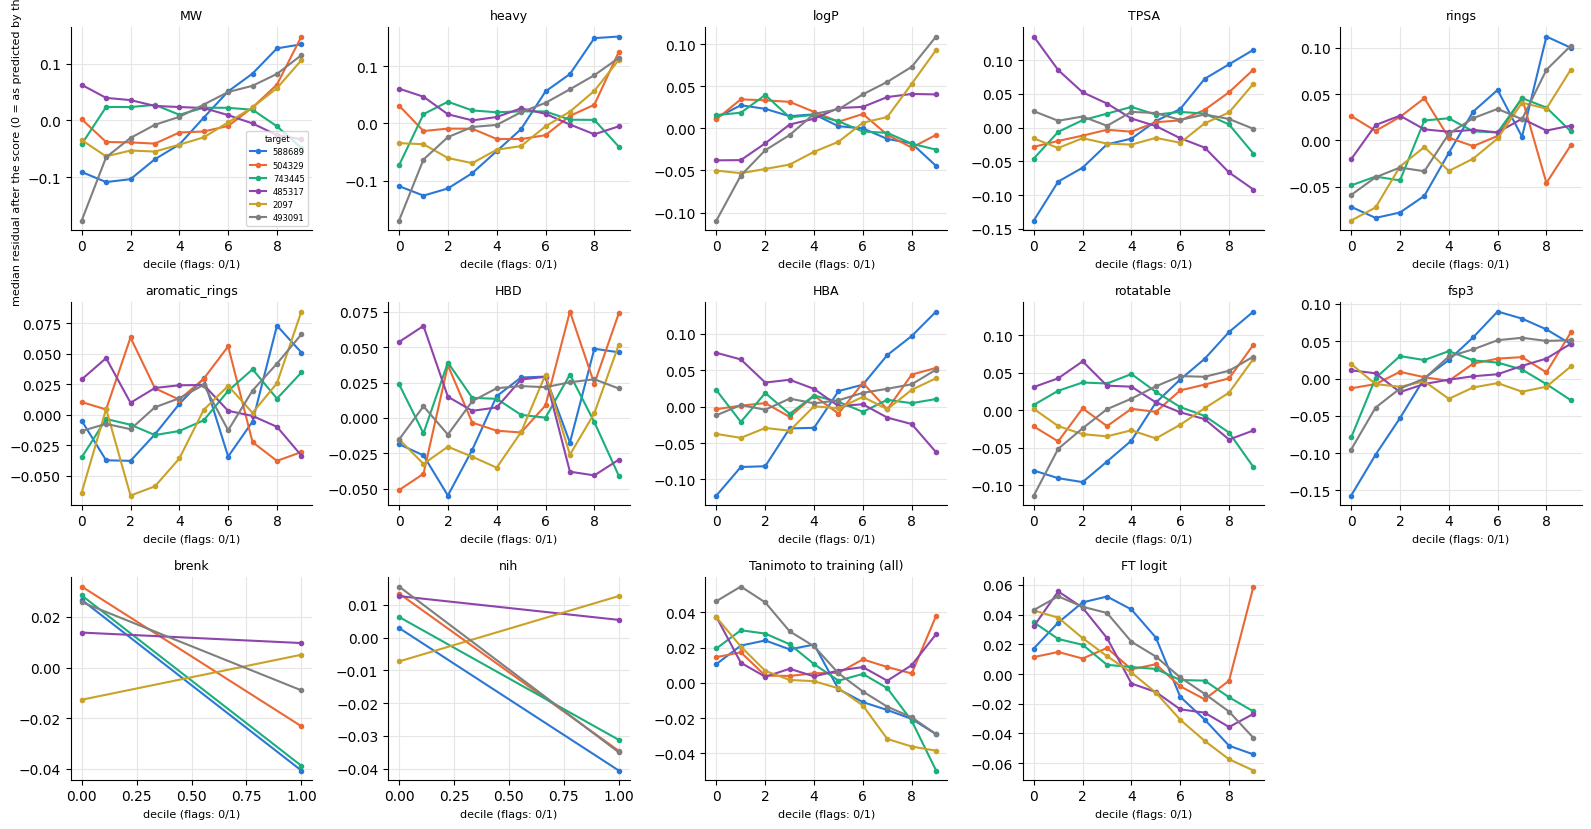

In [6]:
if not len(PDP): print("pending")
else:
    feats = ["MW", "heavy", "logP", "TPSA", "rings", "aromatic_rings", "HBD", "HBA", "rotatable", "fsp3", "brenk", "nih", "Tanimoto to training (all)", "FT logit"]
    for col, ttl in (("variance_rank", "median variance rank"), ("residual", "median residual after the score (0 = as predicted by the score)")):
        fig, axs = plt.subplots(3, 5, figsize=(16, 8.4)); axs = axs.ravel()
        for ax, f in zip(axs, feats):
            for k, t in enumerate(TG):
                d = PDP[(PDP.target == t) & (PDP.feature == f)]
                if len(d): ax.plot(d.bin, d[col], marker="o", ms=3, color=COL[k % 6], label=t)
            ax.set_title(f, fontsize=9); ax.set_xlabel("decile (flags: 0/1)", fontsize=8)
            if col == "variance_rank": ax.set_ylim(0, 1)
        for ax in axs[len(feats):]: ax.axis("off")
        axs[0].set_ylabel(ttl, fontsize=8); axs[0].legend(title="target", fontsize=6, title_fontsize=6); plt.tight_layout(); plt.show()

## 6. Which substructures? ECFP bits that predict what the score leaves over
For each target, a LightGBM model on the 2,048 bits predicts the residual of the score; the bits that carry most of it (gain share) are pooled across targets. A bit that is among a target's top 30 in several targets is a candidate chemical driver. The picture is a compound that has the bit, with the bit's atoms highlighted. 'with / without' = median residual of compounds that have / lack the bit (positive = seeds disagree more than the score predicts).

,targets_in_top30,total_gain,residual_with,residual_without,prevalence
bit,,,,,
314,6,0.10,0.02,0.00,0.28
97,5,0.15,0.02,0.01,0.05
1357,5,0.13,0.06,-0.01,0.12
1928,5,0.08,0.06,0.00,0.13
875,5,0.06,0.02,-0.02,0.47
1917,4,0.10,0.01,-0.00,0.74
675,4,0.09,0.05,-0.00,0.18
1855,4,0.09,0.01,0.00,0.22
350,4,0.09,0.04,-0.01,0.19


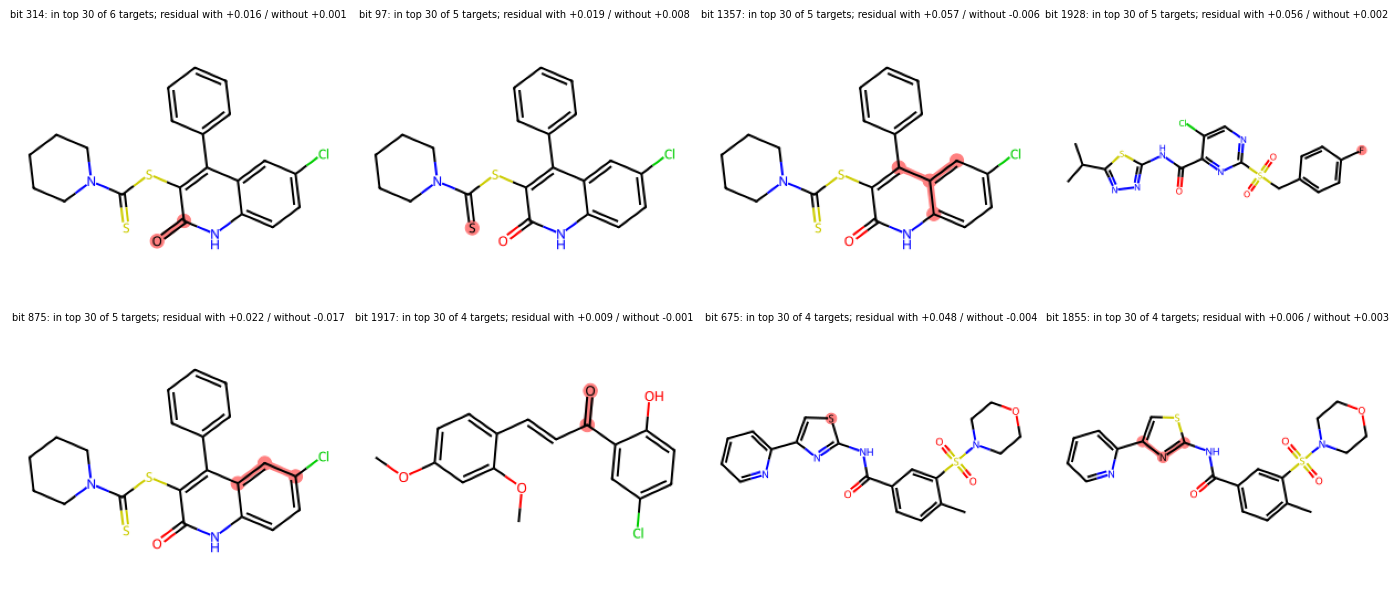

In [7]:
if not len(EB): print("pending")
else:
    pool = EB.groupby("bit").agg(targets_in_top30=("target", "nunique"), total_gain=("gain_share", "sum"), residual_with=("residual_with_bit", "median"), residual_without=("residual_without_bit", "median"), prevalence=("prevalence", "median")).sort_values(["targets_in_top30", "total_gain"], ascending=False)
    display(pool.head(12))
    from rdkit import Chem, RDLogger
    from rdkit.Chem import Draw, rdFingerprintGenerator
    RDLogger.DisableLog("rdApp.*"); gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048); top = pool.head(8).index.tolist(); imgs, caps = [], []
    smi = []
    for t in bc.TARGETS:
        try: smi += list(bc.scores(t).smiles.values[:6000])
        except Exception: pass
    for b in top:
        for s in smi:
            m = Chem.MolFromSmiles(str(s))
            if m is None: continue
            ao = rdFingerprintGenerator.AdditionalOutput(); ao.AllocateBitInfoMap(); gen.GetFingerprint(m, additionalOutput=ao); bi = ao.GetBitInfoMap()
            if b in bi:
                a, r = bi[b][0]; env = Chem.FindAtomEnvironmentOfRadiusN(m, r, a); at = {a}
                for bd in env: at.add(m.GetBondWithIdx(bd).GetBeginAtomIdx()); at.add(m.GetBondWithIdx(bd).GetEndAtomIdx())
                imgs.append(Draw.MolToImage(m, size=(300, 240), highlightAtoms=list(at), highlightBonds=list(env))); caps.append(f"bit {b}: in top 30 of {int(pool.loc[b, 'targets_in_top30'])} targets; residual with {pool.loc[b, 'residual_with']:+.3f} / without {pool.loc[b, 'residual_without']:+.3f}"); break
    fig, axs = plt.subplots(2, 4, figsize=(14, 6.4))
    for ax in axs.ravel(): ax.axis("off")
    for ax, im, c in zip(axs.ravel(), imgs, caps): ax.imshow(im); ax.set_title(c, fontsize=7)
    plt.tight_layout(); plt.show()

## 7. Similarity to the training set: it moves the prediction, not the disagreement
Elsewhere in this repository (notebooks 02 and 03) the benefit of fine-tuning follows the similarity to the training actives. Here the same similarity (highest ECFP4 Tanimoto to a training active, per compound) is compared with four outputs on the whole evaluation set: the fine-tuned score, the shift fine-tuning caused (head-FT minus No-FT logit), the rank gain (percentile after minus before; shown for actives and for inactives) and the across-seed variance of the logit. All five seeds train on the same 300 compounds, so a shift caused by closeness to them is the same in every seed and is not disagreement. Spearman correlations.

,588689,504329,743445,485317,2097,493091,median
fine-tuned score,0.17,0.20,0.15,0.27,0.12,0.33,0.19
shift (head-FT minus No-FT logit),0.14,0.20,0.16,0.16,-0.05,0.25,0.16
"rank gain, actives",0.16,0.30,0.19,-0.03,0.24,0.18,0.18
"rank gain, inactives",0.02,0.13,0.13,0.05,-0.11,0.17,0.09
across-seed variance (logit),-0.11,0.01,-0.04,-0.11,-0.11,-0.23,-0.11
"active rate, top similarity decile / library rate",4.60,3.89,1.93,2.54,5.55,3.38,3.64
"active rate, bottom half / library rate",0.40,0.56,1.07,0.73,0.38,0.53,0.54


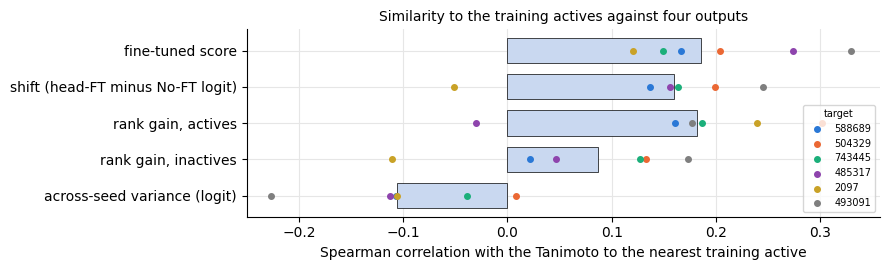

In [8]:
from scipy.stats import spearmanr, rankdata
lg = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6))); rows = {}
for t in bc.TARGETS:
    if SH[t] not in TG: continue
    S = bc.scores(t).set_index("id"); P = lg(S[[f"ft300_p{s}" for s in range(5)]].values); ft = P.mean(1); n0 = lg(S.noft_p.values); var = P.var(1)
    sim = pd.read_csv(bc.AN / t / "tc_train.csv").set_index("Unnamed: 0").reindex(S.index).tc_act.values; y = S.label.values == 1
    rk = lambda x: rankdata(x) / len(x); gain = rk(ft) - rk(n0); top = sim >= np.quantile(sim, .9); lowh = sim <= np.median(sim)
    rows[SH[t]] = {"fine-tuned score": spearmanr(ft, sim)[0], "shift (head-FT minus No-FT logit)": spearmanr(ft - n0, sim)[0], "rank gain, actives": spearmanr(gain[y], sim[y])[0], "rank gain, inactives": spearmanr(gain[~y], sim[~y])[0],
                   "across-seed variance (logit)": spearmanr(var, sim)[0], "active rate, top similarity decile / library rate": y[top].mean() / y.mean(), "active rate, bottom half / library rate": y[lowh].mean() / y.mean()}
if not rows: print("pending")
else:
    SIM = pd.DataFrame(rows)[TG]; display(SIM.assign(median=SIM.median(1)))
    bars(SIM.iloc[:5], "Similarity to the training actives against four outputs", "Spearman correlation with the Tanimoto to the nearest training active", order=list(SIM.index[:5][::-1]))

## 8. Does it survive a split by scaffold?
Sections 2 to 6 use a random 3-fold split of the compounds, so a chemical series can sit on both sides of the split and a model can exploit it (most worrying for the fingerprint). Here the same analyses are repeated with folds grouped by generic Murcko scaffold: every compound of a scaffold is in the same fold, so the model is always tested on scaffolds it has not seen. Left bars: random split; right bars: scaffold split; dots: individual targets (scaffold split).

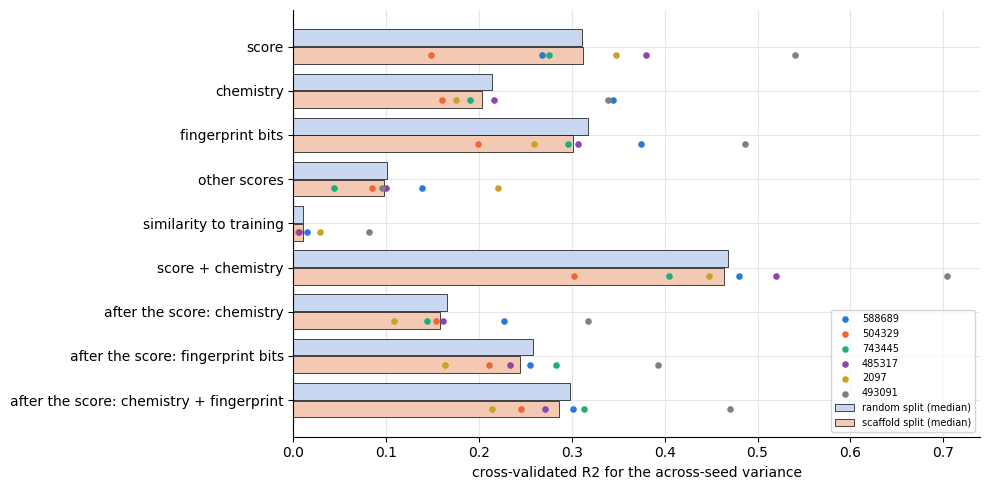

,random split,scaffold split,change
score,0.31,0.31,0.00
chemistry,0.21,0.20,-0.01
fingerprint bits,0.32,0.30,-0.02
other scores,0.10,0.10,-0.00
similarity to training,0.01,0.01,-0.00
score + chemistry,0.47,0.46,-0.00
after the score: chemistry,0.17,0.16,-0.01
after the score: fingerprint bits,0.26,0.24,-0.01
after the score: chemistry + fingerprint,0.30,0.29,-0.01


target,588689,504329,743445,485317,2097,493091,median
score,0.27,0.15,0.28,0.38,0.35,0.54,0.31
chemistry,0.34,0.16,0.19,0.22,0.18,0.34,0.20
fingerprint bits,0.37,0.20,0.30,0.31,0.26,0.49,0.30
other scores,0.14,0.09,0.04,0.10,0.22,0.10,0.10
similarity to training,0.01,0.00,-0.01,0.01,0.03,0.08,0.01
score + chemistry,0.48,0.30,0.40,0.52,0.45,0.70,0.46
after the score: chemistry,0.23,0.15,0.14,0.16,0.11,0.32,0.16
after the score: fingerprint bits,0.26,0.21,0.28,0.23,0.16,0.39,0.24
after the score: chemistry + fingerprint,0.30,0.25,0.31,0.27,0.21,0.47,0.29


In [9]:
if not len(DRS): print("pending: run pipeline_local/variance_drivers.py <target> --scaffold")
else:
    pairs = [("alone", "score (all three)", "score"), ("alone", "chemistry (all 12)", "chemistry"), ("alone", "ECFP4 bits (2048)", "fingerprint bits"), ("alone", "other scores (all 5)", "other scores"), ("alone", "Tanimoto to training (both)", "similarity to training"),
             ("score + chemistry: nothing removed", "-", "score + chemistry"), ("on the residual of the score", "chemistry (all 12)", "after the score: chemistry"), ("on the residual of the score", "ECFP4 bits (2048)", "after the score: fingerprint bits"), ("on the residual of the score", "chemistry + ECFP", "after the score: chemistry + fingerprint")]
    TGS = sorted(DRS.target.unique(), key=lambda x: [SH[t] for t in bc.TARGETS].index(x)); tabR, tabS = {}, {}
    for a, f, n in pairs:
        r = DR[(DR.analysis == a) & (DR.feature == f)].set_index("target").R2; q = DRS[(DRS.analysis == a) & (DRS.feature == f)].set_index("target").R2; tabR[n] = r.reindex(TGS); tabS[n] = q.reindex(TGS)
    TR, TS = pd.DataFrame(tabR).T, pd.DataFrame(tabS).T
    fig, ax = plt.subplots(figsize=(10, 5)); y = np.arange(len(TR))[::-1]
    ax.barh(y + .2, TR.median(1), height=.38, color="#c9d8f0", edgecolor=BLK, linewidth=.5, label="random split (median)"); ax.barh(y - .2, TS.median(1), height=.38, color="#f4c9b3", edgecolor=BLK, linewidth=.5, label="scaffold split (median)")
    for k, t in enumerate(TGS): ax.scatter(TS[t], y - .2, s=14, color=COL[k % 6], zorder=3, label=t)
    ax.set_yticks(y); ax.set_yticklabels(TR.index); ax.set_xlim(0, None); ax.set_xlabel("cross-validated R2 for the across-seed variance"); ax.legend(fontsize=7, loc="lower right"); plt.tight_layout(); plt.show()
    cmp = pd.DataFrame({"random split": TR.median(1), "scaffold split": TS.median(1)}); cmp["change"] = cmp["scaffold split"] - cmp["random split"]; display(cmp); display(TS.assign(median=TS.median(1)))

## Conclusions (computed from the tables above)
Every sentence is an f-string over the results; targets without results are listed as pending and no statement is made for them.

In [10]:
if not len(DR): print("pending: no results yet")
else:
    A = sel("alone"); R = sel("on the residual of the score"); LG = sel("score + chemistry: leave one group out"); FULL = sel("score + chemistry: nothing removed").loc["-"]; P1 = sel("score + one chemistry group")
    m = lambda s: float(np.nanmedian(s)); rng = lambda s: f"{np.nanmin(s):.2f} to {np.nanmax(s):.2f}"
    print(f"Targets analysed: {TG}; pending: {missing}.")
    if len(SDD):
        up = sum(1 for t in TG if SDD[SDD.target == t].sd_logit.iloc[-1] < SDD[SDD.target == t].sd_logit.iloc[0]); upp = sum(1 for t in TG if SDD[SDD.target == t].sd_prob.iloc[-1] > SDD[SDD.target == t].sd_prob.iloc[0])
        print(f"(1) Score and disagreement: on the probability scale the across-seed SD is larger for the highest than for the lowest score decile in {upp} of {len(TG)} targets (the sigmoid); on the logit scale it is SMALLER for the highest decile in {up} of {len(TG)} targets, so higher scores come with a little less disagreement in the scale where the models actually differ.")
    for g in ["score (all three)", "chemistry (all 12)", "Tanimoto to training (both)", "other scores (all 5)"]:
        if g in A.index: print(f"(2) Alone, {g}: R2 median {m(A.loc[g]):.2f} (range {rng(A.loc[g])}).")
    print(f"(3) Score + chemistry together: R2 median {m(FULL):.2f} (range {rng(FULL)}); score alone {m(A.loc['score (all three)']):.2f}, so chemistry adds {m(FULL) - m(A.loc['score (all three)']):.2f}.")
    dg = (-(LG.sub(FULL, axis=1))); dg["median"] = dg.median(1); print("(3) Loss in R2 when a group is removed from score + chemistry (median over targets): " + "; ".join(f"{i}: {v:.2f}" for i, v in dg["median"].sort_values(ascending=False).items()) + ".")
    for g in ["chemistry (all 12)", "ECFP4 bits (2048)", "chemistry + ECFP", "Tanimoto to training (both)", "other scores (all 5)"]:
        if g in R.index: print(f"(4) After the score, {g} still predicts the residual with R2 median {m(R.loc[g]):.2f} (range {rng(R.loc[g])}).")
    if "SIM" in globals():
        mm = SIM.median(1); print(f"(5) Similarity to the training actives against the fine-tuned score: median rho {mm['fine-tuned score']:.2f}; against the shift fine-tuning caused {mm['shift (head-FT minus No-FT logit)']:.2f}; against the rank gain of actives {mm['rank gain, actives']:.2f}; against the across-seed variance {mm['across-seed variance (logit)']:.2f}. Compounds in the top similarity decile are active {mm['active rate, top similarity decile / library rate']:.1f} times as often as the library average, the bottom half {mm['active rate, bottom half / library rate']:.2f} times. Similarity therefore acts on the mean prediction and hardly on the disagreement between seeds, consistent with all seeds sharing one training set.")
    if len(DRS) and "cmp" in globals():
        print("(6) Scaffold-grouped split, median R2 against the random split: " + "; ".join(f"{i}: {r.iloc[1]:.2f} against {r.iloc[0]:.2f}" for i, r in cmp.iterrows()) + ".")
    print("Caveats: R2 is out-of-fold on one library per target, three folds, one model family (section 8 repeats it with scaffold-grouped folds); the seed variance is itself noisy (five seeds), which caps every R2; associations are not mechanisms.")

Targets analysed: ['588689', '504329', '743445', '485317', '2097', '493091']; pending: ['2650', '588549'].
(1) Score and disagreement: on the probability scale the across-seed SD is larger for the highest than for the lowest score decile in 6 of 6 targets (the sigmoid); on the logit scale it is SMALLER for the highest decile in 5 of 6 targets, so higher scores come with a little less disagreement in the scale where the models actually differ.
(2) Alone, score (all three): R2 median 0.31 (range 0.15 to 0.54).
(2) Alone, chemistry (all 12): R2 median 0.21 (range 0.17 to 0.35).
(2) Alone, Tanimoto to training (both): R2 median 0.01 (range -0.00 to 0.08).
(2) Alone, other scores (all 5): R2 median 0.10 (range 0.05 to 0.22).
(3) Score + chemistry together: R2 median 0.47 (range 0.31 to 0.71); score alone 0.31, so chemistry adds 0.16.
(3) Loss in R2 when a group is removed from score + chemistry (median over targets): score (all three): 0.24; size (MW, heavy atoms, rings, aromatic rings, rot